<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/basic_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 기본 CNN(합성곱 신경망) 이해하기

> **비전공자를 위한 친절한 입문 노트북 + 직접 코딩 실습 포함**

---

## 학습 목표

이 노트북을 끝내면 다음을 이해하게 됩니다.

1. **왜 CNN인가?** — 일반 신경망(FC)으로 이미지를 다루면 무엇이 문제인지
2. **합성곱(Convolution)** 이 실제로 무엇을 하는 연산인지 (도장찍기 비유)
3. **필터가 학습된다는 게 무슨 뜻**인지 (엣지 검출 직접 보기)
4. **풀링, ReLU** 가 왜 필요한지
5. 직접 코드로 **합성곱, 풀링, ReLU** 를 만들어 미니 CNN을 통과시켜 봅니다

## 진행 순서

| 단계 | 내용 |
|---|---|
| 1 | 왜 CNN? — 일반 신경망의 한계 |
| 2 | 합성곱이란? — 도장찍기 비유 |
| 3 | 필터의 마법 — 엣지 검출 직접 보기 |
| 4 | [연습 1] 한 위치의 합성곱 계산 |
| 5 | [연습 2] 전체 합성곱 구현 (슬라이딩 윈도우) |
| 6 | 패딩과 스트라이드 — 출력 크기 공식 |
| 7 | [연습 3] Max Pooling 구현 |
| 8 | [연습 4] ReLU 활성화 함수 |
| 9 | 미니 CNN 통과시키기 — 만든 함수로 끝까지! |
| 10 | 정리 |

## 실습 코드 사용법

이 노트북에는 **4개의 빈칸 채우기 연습**이 있습니다.

- **연습 셀**: 빈칸(`...`)을 채워서 함수를 완성합니다
- **자가 검증 셀**: 실행하면 정답인지 자동으로 알려줍니다
- **정답 보기**: 충분히 시도해본 뒤 펼쳐보세요

> **이전 시간 복습**: 이미지 처리 노트북에서 (N, H, W, C) 4D 텐서까지 만들었죠.
> 오늘은 그 텐서를 받아 처리하는 **CNN의 핵심 부품**을 배웁니다.

## 0. 환경 준비 (한글 폰트 설정)

In [1]:
# 한글 폰트 설치 (코랩 1회만)
!apt-get -qq install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fe = fm.FontEntry(fname=font_path, name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

import numpy as np
np.random.seed(42)

print("환경 준비 완료!")

환경 준비 완료!


## 1. 왜 CNN인가? — 일반 신경망의 한계

### 문제 상황: 224x224 컬러 사진을 일반 신경망(FC)에 넣는다면?

이전 시간에 배운 것처럼, 일반적인 신경망(Fully Connected, FC)은 모든 입력과 모든 뉴런이 완전히 연결됩니다.

- 입력 픽셀 개수: 224 × 224 × 3 = **150,528개**
- 첫 번째 은닉층 뉴런 1,000개라고 하면?
- 가중치 개수: 150,528 × 1,000 = **약 1억 5천만 개!**

### 두 가지 큰 문제

**문제 1: 파라미터 폭발**
- 가중치가 너무 많으면 메모리도 많이 쓰고, 학습도 어렵고, 과적합도 잘 됩니다.

**문제 2: 위치가 바뀌면 다시 학습해야 함**
- "왼쪽 위에 있는 고양이" 와 "오른쪽 아래에 있는 고양이" 를 일반 신경망은 **완전히 다르게** 봅니다.
- 같은 고양이인데 위치만 다를 뿐인데도, 모든 위치에 대해 따로따로 학습이 필요합니다.

### CNN의 두 가지 핵심 아이디어

| 아이디어 | 효과 | 비유 |
|---|---|---|
| **지역 연결 (Local Connectivity)** | 작은 영역만 보고 처리 | 책을 한 페이지씩 읽기 (전체를 한 번에 보지 않음) |
| **가중치 공유 (Weight Sharing)** | 같은 필터를 모든 위치에 적용 | 같은 도장을 종이 여러 곳에 찍기 |

이 두 가지로 **파라미터를 100배 이상 줄이면서**, **위치 무관**하게 패턴을 찾을 수 있게 됩니다.

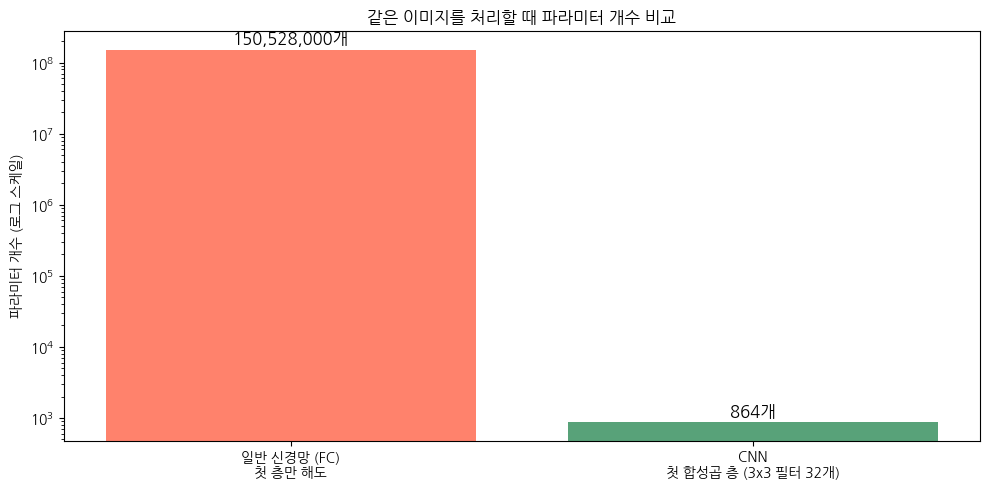

FC 파라미터:      150,528,000개
CNN 파라미터:             864개
비율:          CNN이 174,222배 적음!


In [2]:
# FC vs CNN 파라미터 비교
fig, ax = plt.subplots(figsize=(10, 5))

# 224x224x3 입력 → 1000 뉴런 가정
fc_params = 224 * 224 * 3 * 1000

# CNN: 3x3 필터 32개 (첫 conv layer)
cnn_params = 3 * 3 * 3 * 32  # 필터크기 x 입력채널 x 필터개수

categories = ['일반 신경망 (FC)\n첫 층만 해도', 'CNN\n첫 합성곱 층 (3x3 필터 32개)']
values = [fc_params, cnn_params]
colors = ['tomato', 'seagreen']

bars = ax.bar(categories, values, color=colors, alpha=0.8)
ax.set_yscale('log')
ax.set_ylabel('파라미터 개수 (로그 스케일)')
ax.set_title('같은 이미지를 처리할 때 파라미터 개수 비교')

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v * 1.2,
            f'{v:,}개', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout(); plt.show()

print(f"FC 파라미터:  {fc_params:>15,}개")
print(f"CNN 파라미터: {cnn_params:>15,}개")
print(f"비율:          CNN이 {fc_params // cnn_params:,}배 적음!")

## 2. 합성곱(Convolution)이란? — 도장찍기 비유

### 비유: 작은 도장을 종이 위에서 미끄러뜨리며 찍기

여러분이 **작은 도장**(stamp)을 가지고 있다고 상상해 보세요.
이 도장에는 어떤 모양이 새겨져 있고, 도장을 종이 위 여러 곳에 찍을 수 있습니다.

> **합성곱 = 작은 도장을 이미지 위에서 슬라이딩(sliding)하며, 매 위치에서 "이 도장이 얼마나 잘 맞는지" 점수를 매기는 일**

### 구체적으로

1. 작은 **필터(filter)** 또는 **커널(kernel)** 을 준비합니다 (예: 3x3 크기)
2. 이미지의 왼쪽 위부터 시작해서, 필터와 이미지의 같은 위치를 **곱하고 더합니다**
3. 그 결과 한 숫자가 나옵니다 → 출력의 한 픽셀
4. 필터를 한 칸 옆으로 옮겨서 같은 일을 반복
5. 이미지 전체를 다 훑으면 → 출력 이미지(특징맵, feature map) 완성

### 왜 "필터" 라고 부르나?

도장에 새겨진 모양이 **"이런 패턴이 있는지 찾아라"** 라는 명령이기 때문입니다.
- 세로선 모양 도장 → 이미지의 세로선이 있는 곳에 큰 점수
- 가로선 모양 도장 → 이미지의 가로선이 있는 곳에 큰 점수
- 동그라미 모양 도장 → 동그라미가 있는 곳에 큰 점수

### 핵심 포인트

> **같은 도장(필터)이 모든 위치에서 사용됩니다.**
> 이게 바로 "가중치 공유" 입니다. 도장 1개의 9개 숫자(3x3)만 학습하면 끝!

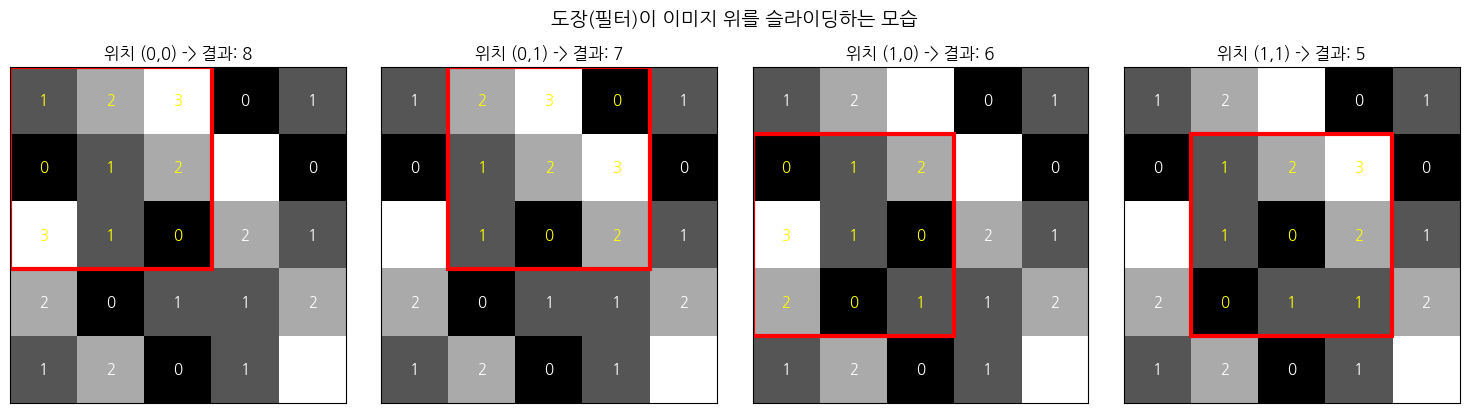

위 4개 위치 외에도, 5x5 이미지에 3x3 필터를 적용하면
총 3x3 = 9개 위치를 거치며 9개 숫자(=출력 이미지)가 만들어집니다.


In [3]:
# 슬라이딩 윈도우 시각화
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# 5x5 입력 이미지
img = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 0],
    [3, 1, 0, 2, 1],
    [2, 0, 1, 1, 2],
    [1, 2, 0, 1, 3],
])

# 3x3 필터
kernel = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1],
])

# 4단계 슬라이딩 시각화
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for ax, (i, j) in zip(axes, positions):
    ax.imshow(img, cmap='gray', vmin=0, vmax=3)
    # 필터가 위치한 영역을 빨간 사각형으로
    rect = plt.Rectangle((j - 0.5, i - 0.5), 3, 3,
                          fill=False, edgecolor='red', linewidth=3)
    ax.add_patch(rect)

    # 픽셀 값 표시
    for ii in range(5):
        for jj in range(5):
            color = 'yellow' if (i <= ii < i+3 and j <= jj < j+3) else 'white'
            ax.text(jj, ii, str(img[ii, jj]), ha='center', va='center',
                    color=color, fontweight='bold', fontsize=11)

    # 이 위치에서 합성곱 결과 계산
    patch = img[i:i+3, j:j+3]
    conv_value = (patch * kernel).sum()
    ax.set_title(f'위치 ({i},{j}) -> 결과: {conv_value}')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('도장(필터)이 이미지 위를 슬라이딩하는 모습', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("위 4개 위치 외에도, 5x5 이미지에 3x3 필터를 적용하면")
print("총 3x3 = 9개 위치를 거치며 9개 숫자(=출력 이미지)가 만들어집니다.")

## 3. 필터의 마법 — 엣지 검출 직접 보기

### 신기한 사실

특정 모양의 필터를 만들면, 이미지의 **세로선, 가로선, 대각선 같은 특징을 자동으로 검출**할 수 있습니다.

### 자주 쓰는 필터들

| 필터 | 모양 | 효과 |
|---|---|---|
| **세로 엣지 검출** | `[[-1,0,1],[-1,0,1],[-1,0,1]]` | 세로 방향 경계가 강조됨 |
| **가로 엣지 검출** | `[[-1,-1,-1],[0,0,0],[1,1,1]]` | 가로 방향 경계가 강조됨 |
| **블러(흐림)** | `[[1,1,1],[1,1,1],[1,1,1]]/9` | 평균을 내서 흐릿해짐 |
| **샤프닝** | `[[0,-1,0],[-1,5,-1],[0,-1,0]]` | 경계가 더 또렷해짐 |

### CNN의 진짜 마법

> **이 필터들을 사람이 직접 설계하는 게 아니라, 학습 데이터로부터 자동으로 찾아냅니다!**

옛날 컴퓨터 비전에서는 "Sobel 필터", "Gaussian 필터" 같은 걸 사람이 만들어 썼지만,
CNN은 학습 과정에서 **그 데이터에 가장 잘 맞는 필터를 스스로** 만들어 갑니다.

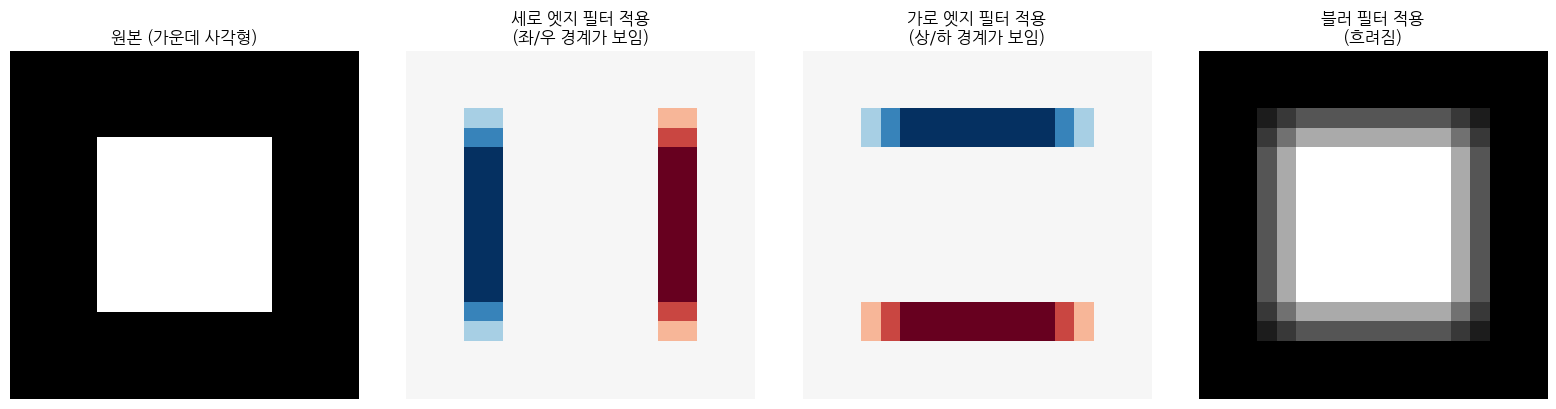

같은 이미지에 다른 필터를 적용하면 다른 특징이 강조됩니다!
CNN은 학습으로 이런 필터들을 수십~수백 개 만들어 냅니다.


In [4]:
# 간단한 도형 이미지에 다양한 필터 적용해보기
# 가운데에 사각형이 있는 흑백 이미지
test_img = np.zeros((20, 20), dtype=np.float32)
test_img[5:15, 5:15] = 1.0   # 가운데 흰 사각형

# 3가지 필터
filter_vertical = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
], dtype=np.float32)

filter_horizontal = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1],
], dtype=np.float32)

filter_blur = np.ones((3, 3), dtype=np.float32) / 9

# 합성곱 함수 (간단 버전, 곧 직접 만들 예정)
def simple_conv(img, kernel):
    H, W = img.shape
    kH, kW = kernel.shape
    out = np.zeros((H - kH + 1, W - kW + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = (img[i:i+kH, j:j+kW] * kernel).sum()
    return out

# 결과 시각화
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(test_img, cmap='gray')
axes[0].set_title('원본 (가운데 사각형)')
axes[0].axis('off')

axes[1].imshow(simple_conv(test_img, filter_vertical), cmap='RdBu')
axes[1].set_title('세로 엣지 필터 적용\n(좌/우 경계가 보임)')
axes[1].axis('off')

axes[2].imshow(simple_conv(test_img, filter_horizontal), cmap='RdBu')
axes[2].set_title('가로 엣지 필터 적용\n(상/하 경계가 보임)')
axes[2].axis('off')

axes[3].imshow(simple_conv(test_img, filter_blur), cmap='gray')
axes[3].set_title('블러 필터 적용\n(흐려짐)')
axes[3].axis('off')

plt.tight_layout(); plt.show()

print("같은 이미지에 다른 필터를 적용하면 다른 특징이 강조됩니다!")
print("CNN은 학습으로 이런 필터들을 수십~수백 개 만들어 냅니다.")

## 4. 합성곱 한 위치는 어떻게 계산되나?

전체 합성곱은 결국 **한 위치 계산을 여러 번 반복**한 것일 뿐입니다.
한 위치만 정확히 이해하면 끝!

### 한 위치 합성곱의 3단계

1. **이미지에서 필터 크기만큼 잘라내기** (patch)
2. **패치와 필터를 같은 위치끼리 곱하기** (element-wise multiplication)
3. **모든 곱을 다 더하기** (sum)

수식으로:
$$\text{출력} = \sum_{i, j} \text{이미지}[i, j] \times \text{필터}[i, j]$$

### 구체적 예시 (3x3 필터)

```
이미지 패치        필터              곱셈                합산
┌─────┐          ┌─────┐          ┌─────────┐
│1 2 3│          │1 0 1│          │1 0 3    │
│0 1 2│    *     │0 1 0│    =     │0 1 0    │   --> 모두 더하기 = 8
│3 1 0│          │1 0 1│          │3 0 0    │
└─────┘          └─────┘          └─────────┘
```

> **핵심**: 곱셈은 "같은 자리끼리만" 합니다. 행렬 곱셈이 아니에요!

---

## 연습 1: 한 위치의 합성곱 값을 계산하는 함수

### 만들어야 할 함수
```python
conv_at(patch, kernel)
# 입력: patch (H, W), kernel (H, W) - 같은 크기의 두 행렬
# 출력: 한 숫자 (스칼라)
```

### 힌트 — 1단계로 끝!

1. **곱하기 + 더하기**: numpy의 element-wise 곱셈과 sum을 활용
   - `patch * kernel`  → 같은 자리끼리 곱한 행렬
   - `(patch * kernel).sum()`  → 모든 원소 더하기

> **참고**: numpy의 `*` 연산자는 행렬 곱셈이 아니라 **같은 자리끼리 곱셈**(element-wise)입니다.
> 행렬 곱셈은 `@` 또는 `np.dot()` 인데, 합성곱에는 element-wise 곱이 필요합니다!

In [5]:
# 빈칸을 채워서 함수를 완성하세요!
def conv_at(patch, kernel):
    # TODO: patch와 kernel을 같은 자리끼리 곱한 뒤, 모두 더하기
    return (patch * kernel).sum()   # (힌트: (patch * kernel).sum())

In [6]:
# 자가 검증
try:
    # 검증 1) 위 마크다운의 예시 그대로
    patch = np.array([[1, 2, 3],
                       [0, 1, 2],
                       [3, 1, 0]])
    kernel = np.array([[1, 0, 1],
                        [0, 1, 0],
                        [1, 0, 1]])
    result = conv_at(patch, kernel)
    expected = 1*1 + 2*0 + 3*1 + 0*0 + 1*1 + 2*0 + 3*1 + 1*0 + 0*1  # = 8

    # 검증 2) 모두 0인 패치 -> 0
    zero_patch = np.zeros((3, 3))
    result_zero = conv_at(zero_patch, kernel)

    # 검증 3) 단위 행렬과 자기자신
    eye = np.eye(3)
    result_eye = conv_at(eye, eye)  # 대각선 1*1 세 번 = 3

    if (result == expected and result_zero == 0 and result_eye == 3):
        print(f"정답입니다!")
        print(f"   예시 패치 결과: {result}  (기대: {expected})")
        print(f"   영행렬 결과:   {result_zero}")
        print(f"   단위행렬 결과: {result_eye}")
    else:
        print(f"다시 시도해보세요.")
        print(f"   예시 결과: {result} (기대: {expected})")
except Exception as e:
    print(f"에러 발생: {e}")
    print(f"   -> 빈칸을 채웠는지 확인하세요.")

정답입니다!
   예시 패치 결과: 8  (기대: 8)
   영행렬 결과:   0.0
   단위행렬 결과: 3.0


<details>
<summary>정답 보기 (클릭)</summary>

```python
def conv_at(patch, kernel):
    return (patch * kernel).sum()
```

**해설**:
- `patch * kernel`: 같은 자리끼리 곱한 새 행렬 (element-wise)
- `.sum()`: 모든 원소를 합쳐서 한 숫자 만들기
- 이 두 줄이 합성곱의 본질입니다!

</details>

In [7]:
# 표준 정답 함수 (다음 진행을 위해 실행)
def conv_at(patch, kernel):
    return (patch * kernel).sum()

print("conv_at 함수 준비 완료!")

conv_at 함수 준비 완료!


## 5. 전체 합성곱 — 슬라이딩 윈도우

이제 한 위치 계산은 이해했으니, **모든 위치를 다 훑어가면서** 출력 이미지를 만들면 끝입니다.

### 출력 크기는 어떻게 정해질까?

5x5 이미지에 3x3 필터를 적용하면 출력은 몇 x 몇일까요?

> 직접 슬라이딩하다 보면 자연스럽게 알 수 있어요. 가로로:
> - 위치 0, 1, 2 — 그 다음은 필터가 이미지를 벗어남
> - 즉, **5 - 3 + 1 = 3** 개 위치

### 출력 크기 공식 (패딩 없을 때, 스트라이드 1일 때)

> **출력 크기 = 입력 크기 - 필터 크기 + 1**

- 입력 28x28, 필터 3x3 → 출력 26x26
- 입력 224x224, 필터 5x5 → 출력 220x220
- 입력 32x32, 필터 7x7 → 출력 26x26

---

## 연습 2: 전체 합성곱 함수 만들기

### 만들어야 할 함수
```python
conv2d(image, kernel)
# 입력: image (H_in, W_in), kernel (kH, kW)
# 출력: feature map (H_out, W_out)
```

### 힌트 — 4단계로!

1. **출력 크기 계산하기**:
   - `H_out = H_in - kH + 1`
   - `W_out = W_in - kW + 1`

2. **출력을 0으로 채워진 배열로 초기화**:
   - `out = np.zeros((H_out, W_out))`

3. **이중 for 반복문으로 모든 위치 순회**:
   - `for i in range(H_out):`
   -   `for j in range(W_out):`

4. **각 위치에서 conv_at 호출**:
   - `patch = image[i:i+kH, j:j+kW]`
   - `out[i, j] = conv_at(patch, kernel)`

### 슬라이싱 주의

`image[i:i+kH, j:j+kW]` 는 "i번째 행부터 kH개 행, j번째 열부터 kW개 열" 을 잘라냅니다.
즉, 필터와 같은 크기의 패치를 정확히 꺼내옵니다.

In [8]:
# 빈칸을 채워서 함수를 완성하세요!
def conv2d(image, kernel):
    H_in, W_in = image.shape
    kH, kW = kernel.shape

    # TODO 1: 출력 크기 계산
    H_out = H_in - kH + 1   # (힌트: H_in - kH + 1)
    W_out = W_in - kW + 1   # (힌트: W_in - kW + 1)

    # TODO 2: 0으로 채워진 출력 배열 만들기
    out = np.zeros((H_out, W_out))     # (힌트: np.zeros((H_out, W_out)))

    # TODO 3: 모든 위치 순회
    for i in range(H_out):
        for j in range(W_out):
            # TODO 4: 패치 잘라내고 conv_at 적용
            patch = image[i:i+kH, j:j+kW]               # (힌트: image[i:i+kH, j:j+kW])
            out[i, j] = conv_at(patch, kernel)           # (힌트: conv_at(patch, kernel))

    return out

In [9]:
# 자가 검증
try:
    # 검증 1) 5x5 이미지 + 3x3 필터 -> 출력 3x3
    img = np.array([
        [1, 2, 3, 0, 1],
        [0, 1, 2, 3, 0],
        [3, 1, 0, 2, 1],
        [2, 0, 1, 1, 2],
        [1, 2, 0, 1, 3],
    ], dtype=np.float32)
    kernel = np.array([[1, 0, 1],
                        [0, 1, 0],
                        [1, 0, 1]], dtype=np.float32)

    out = conv2d(img, kernel)

    # 위치 (0,0) 의 값은 위에서 계산했던 8
    val_00 = 1*1 + 2*0 + 3*1 + 0*0 + 1*1 + 2*0 + 3*1 + 1*0 + 0*1  # = 8

    # 검증 2) 모두 1인 이미지 + 모두 1인 필터 -> 모든 위치가 9
    ones_img = np.ones((4, 4))
    ones_kernel = np.ones((2, 2))
    out_ones = conv2d(ones_img, ones_kernel)
    # 모든 위치에서 1*1 + 1*1 + 1*1 + 1*1 = 4

    shape_ok = out.shape == (3, 3)
    val_ok = abs(out[0, 0] - val_00) < 1e-6
    ones_ok = out_ones.shape == (3, 3) and (out_ones == 4).all()

    if shape_ok and val_ok and ones_ok:
        print(f"정답입니다!")
        print(f"   5x5 + 3x3 -> 출력 shape: {out.shape}")
        print(f"   (0,0) 위치 값: {out[0, 0]}  (기대: {val_00})")
        print(f"   4x4 ones + 2x2 ones -> 모든 위치가 4: 통과!")
    else:
        print(f"다시 시도해보세요.")
        print(f"   shape: {out.shape} (기대: (3, 3))")
        print(f"   (0,0): {out[0, 0]} (기대: {val_00})")
except Exception as e:
    print(f"에러 발생: {e}")

정답입니다!
   5x5 + 3x3 -> 출력 shape: (3, 3)
   (0,0) 위치 값: 8.0  (기대: 8)
   4x4 ones + 2x2 ones -> 모든 위치가 4: 통과!


<details>
<summary>정답 보기 (클릭)</summary>

```python
def conv2d(image, kernel):
    H_in, W_in = image.shape
    kH, kW = kernel.shape
    H_out = H_in - kH + 1
    W_out = W_in - kW + 1
    out = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            patch = image[i:i+kH, j:j+kW]
            out[i, j] = conv_at(patch, kernel)
    return out
```

**축하합니다!**
이걸 만들 수 있다면 이제 **CNN의 핵심 연산을 직접 구현한 것**입니다.
PyTorch, TensorFlow의 `Conv2d` 레이어가 안에서 하는 일이 정확히 이거예요
(다만 GPU에서 훨씬 빠르게 병렬 처리하는 차이가 있죠).

</details>

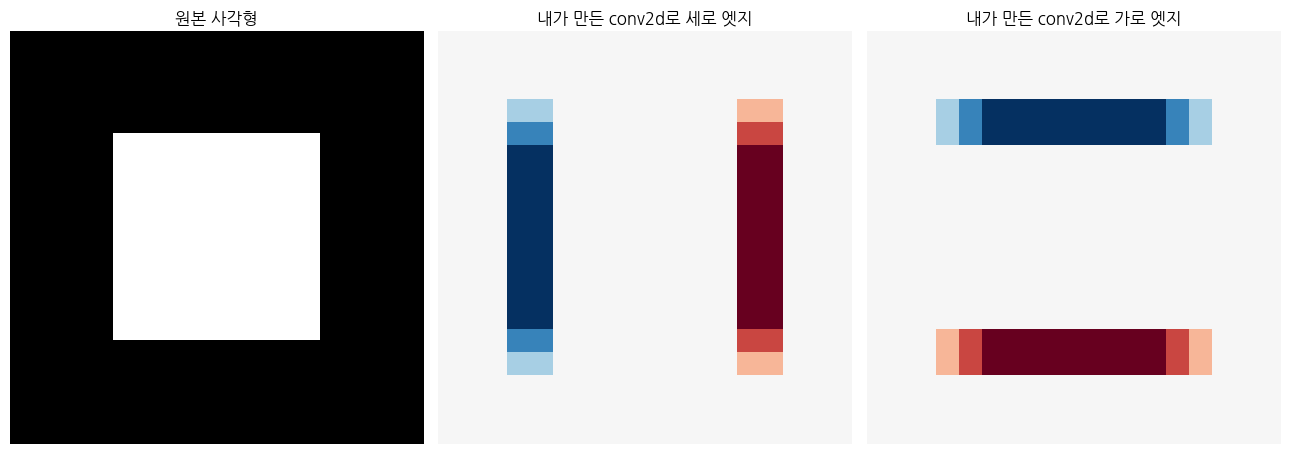

내가 만든 함수가 진짜 엣지를 검출했습니다!


In [10]:
# 표준 정답 함수
def conv2d(image, kernel):
    H_in, W_in = image.shape
    kH, kW = kernel.shape
    H_out, W_out = H_in - kH + 1, W_in - kW + 1
    out = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            out[i, j] = conv_at(image[i:i+kH, j:j+kW], kernel)
    return out

# 우리가 만든 conv2d로 다시 엣지 검출!
square = np.zeros((20, 20), dtype=np.float32)
square[5:15, 5:15] = 1.0

vert_filter = np.array([[-1, 0, 1]] * 3, dtype=np.float32)
horz_filter = np.array([[-1]*3, [0]*3, [1]*3], dtype=np.float32)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(square, cmap='gray'); axes[0].set_title('원본 사각형'); axes[0].axis('off')
axes[1].imshow(conv2d(square, vert_filter), cmap='RdBu')
axes[1].set_title('내가 만든 conv2d로 세로 엣지'); axes[1].axis('off')
axes[2].imshow(conv2d(square, horz_filter), cmap='RdBu')
axes[2].set_title('내가 만든 conv2d로 가로 엣지'); axes[2].axis('off')
plt.tight_layout(); plt.show()
print("내가 만든 함수가 진짜 엣지를 검출했습니다!")

## 6. 패딩(Padding)과 스트라이드(Stride)

위에서 만든 합성곱은 **출력 크기가 입력보다 작아지는** 문제가 있습니다.

> 28x28 이미지에 3x3 필터를 적용하면 26x26이 됨
> 이걸 여러 번 쌓으면 이미지가 점점 작아져서 결국 사라짐

### 패딩(Padding) — 이미지 주변에 0 두르기

해결책: 이미지 가장자리에 **0으로 된 테두리** 를 추가합니다.

```
원본 (3x3)         0으로 패딩 (5x5)
┌─────┐           ┌─────────┐
│1 2 3│           │0 0 0 0 0│
│4 5 6│   ─->    │0 1 2 3 0│
│7 8 9│           │0 4 5 6 0│
└─────┘           │0 7 8 9 0│
                  │0 0 0 0 0│
                  └─────────┘
```

**효과**:
- 출력 크기를 **입력과 똑같이** 유지할 수 있음
- 이미지 가장자리 정보도 손실 없이 사용

### 스트라이드(Stride) — 도장을 몇 칸씩 옮길까?

지금까지는 도장을 **한 칸씩** 옮겼지만, **두 칸씩, 세 칸씩** 옮길 수도 있습니다.
이걸 스트라이드라고 합니다.

| Stride | 효과 |
|---|---|
| **1** | 모든 위치 다 훑음 (기본) |
| **2** | 출력이 약 절반 크기로 줄어듦 (다운샘플링 효과) |
| **3** | 출력이 약 1/3 크기 |

### 출력 크기 일반 공식

> **출력 크기 = (입력 크기 + 2·패딩 - 필터 크기) / 스트라이드 + 1**

| 입력 | 필터 | 패딩 | 스트라이드 | 출력 |
|---|---|---|---|---|
| 28x28 | 3x3 | 0 | 1 | (28-3+1)=26 |
| 28x28 | 3x3 | **1** | 1 | (28+2-3+1)=**28 (그대로!)** |
| 28x28 | 3x3 | 0 | **2** | (28-3)/2+1=**13 (절반)** |

원본:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

패딩 후 (가장자리 0 추가):
[[0 0 0 0 0]
 [0 1 2 3 0]
 [0 4 5 6 0]
 [0 7 8 9 0]
 [0 0 0 0 0]]

shape 변화: (3, 3) -> (5, 5)


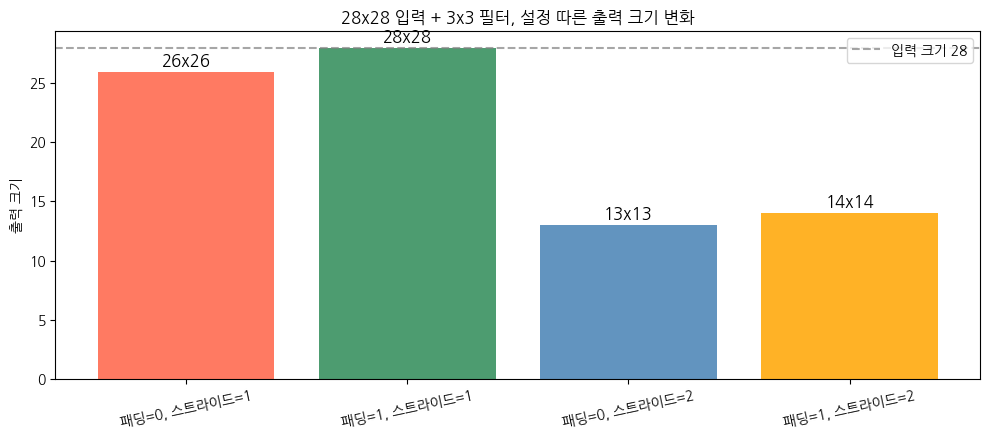

In [11]:
# 패딩 실습 (numpy의 np.pad 사용)
img_small = np.array([[1, 2, 3],
                       [4, 5, 6],
                       [7, 8, 9]])

# 가장자리에 0을 1픽셀씩 추가
img_padded = np.pad(img_small, pad_width=1, mode='constant', constant_values=0)
print("원본:")
print(img_small)
print(f"\n패딩 후 (가장자리 0 추가):")
print(img_padded)
print(f"\nshape 변화: {img_small.shape} -> {img_padded.shape}")

# 28x28에 3x3 conv를 적용했을 때 출력 크기 비교
fig, ax = plt.subplots(figsize=(10, 4.5))
configs = [
    ('패딩=0, 스트라이드=1', 28 - 3 + 1, 'tomato'),
    ('패딩=1, 스트라이드=1', 28 + 2 - 3 + 1, 'seagreen'),
    ('패딩=0, 스트라이드=2', (28 - 3) // 2 + 1, 'steelblue'),
    ('패딩=1, 스트라이드=2', (28 + 2 - 3) // 2 + 1, 'orange'),
]
labels = [c[0] for c in configs]
sizes = [c[1] for c in configs]
colors = [c[2] for c in configs]

bars = ax.bar(labels, sizes, color=colors, alpha=0.85)
for bar, s in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, s + 0.5,
            f'{s}x{s}', ha='center', fontsize=12, fontweight='bold')
ax.axhline(28, linestyle='--', color='gray', alpha=0.7, label='입력 크기 28')
ax.set_ylabel('출력 크기')
ax.set_title('28x28 입력 + 3x3 필터, 설정 따른 출력 크기 변화')
ax.legend()
plt.xticks(rotation=12)
plt.tight_layout(); plt.show()

## 7. Max Pooling — 핵심만 남기는 다운샘플링

### 비유: 동네 대표 뽑기

> 한 동네(예: 2x2 영역)에서 **가장 큰 시그널만 살아남는** 토너먼트입니다.
> "이 영역 어딘가에 강한 패턴이 있다" 는 정보만 남기고, 정확히 어느 픽셀이었는지는 버립니다.

### 작동 방식 (2x2 풀링, stride=2)

```
입력 (4x4)         Max Pooling (2x2)        출력 (2x2)
┌─────────┐       (2x2 영역의 max)         ┌─────┐
│1 3│2 4│           ┌─────┐                │     │
│5 6│7 8│    ─-->  │ 6 8 │                │ 6  8│
├─────────┤        │ 5 9 │                │ 5  9│
│2 5│3 4│           └─────┘                └─────┘
│4 1│9 2│
└─────────┘
```

좌상단 2x2 영역 [1,3,5,6] → max = 6 → 출력 (0,0) 위치

### 풀링의 효과

| 효과 | 설명 |
|---|---|
| **크기 축소** | 4x4 → 2x2 로 줄어 다음 연산이 빨라짐 |
| **위치 변화에 강건** | 패턴이 한두 픽셀 흔들려도 결과가 같음 |
| **파라미터 없음** | 학습할 가중치가 없어 가벼움 |

### Max Pooling vs Average Pooling

- **Max Pooling**: 영역의 **최댓값** 만 살림 → 강한 시그널 보존 (현재 표준)
- **Average Pooling**: 영역의 **평균** 사용 → 부드럽지만 강한 신호가 희석됨

---

## 연습 3: Max Pooling 함수 만들기 (2x2 풀링, stride=2)

### 만들어야 할 함수
```python
max_pool_2x2(image)
# 입력: image (H, W) - H, W는 짝수라고 가정
# 출력: pooled (H/2, W/2)
```

### 힌트 — 합성곱과 거의 같은 구조!

1. **출력 크기 계산**:
   - `H_out = H // 2`  (정수 나눗셈)
   - `W_out = W // 2`

2. **0으로 초기화된 출력 배열**:
   - `out = np.zeros((H_out, W_out))`

3. **이중 for 반복문**:
   - `for i in range(H_out):`
   -   `for j in range(W_out):`

4. **각 위치에서 2x2 패치의 최댓값 구하기**:
   - 패치 잘라내기: `image[i*2:(i+1)*2, j*2:(j+1)*2]`
   - 그 패치의 최댓값: `.max()` 메서드 사용

### 합성곱과의 차이

| | 합성곱 | Max Pooling |
|---|---|---|
| 슬라이딩 간격 | 1 | **2** (i*2, j*2 사용) |
| 패치에 하는 일 | 필터와 곱하고 합산 | **max() 만** |
| 학습 파라미터 | 필터 가중치 | **없음** |

In [16]:
# 빈칸을 채워서 max pooling 함수를 완성하세요!
def max_pool_2x2(image):
    H, W = image.shape

    # TODO 1: 출력 크기 계산 (입력의 절반)
    H_out = H//2   # (힌트: H // 2)
    W_out = W//2   # (힌트: W // 2)

    # TODO 2: 0으로 채워진 출력 배열
    out = np.zeros((H_out, W_out))   # (힌트: np.zeros((H_out, W_out)))

    # TODO 3: 모든 위치 순회
    for i in range(H_out):
        for j in range(W_out):
            # TODO 4: 2x2 패치 잘라내고 최댓값 구하기
            patch = image[i*2:(i+1)*2, j*2:(j+1)*2]                # (힌트: image[i*2:(i+1)*2, j*2:(j+1)*2])
            out[i, j] = patch.max()             # (힌트: patch.max())

    return out

In [17]:
# 자가 검증
try:
    # 검증 1) 위 마크다운의 예시
    img = np.array([
        [1, 3, 2, 4],
        [5, 6, 7, 8],
        [2, 5, 3, 4],
        [4, 1, 9, 2],
    ])
    out = max_pool_2x2(img)
    expected = np.array([[6, 8],
                          [5, 9]])

    # 검증 2) 모두 같은 값 -> 변화 없음 (값은 동일)
    flat = np.full((4, 4), 7)
    out_flat = max_pool_2x2(flat)
    expected_flat = np.full((2, 2), 7)

    # 검증 3) 6x6 입력 -> 3x3 출력
    big = np.arange(36).reshape(6, 6)
    out_big = max_pool_2x2(big)

    shape_ok = out.shape == (2, 2) and out_big.shape == (3, 3)
    val_ok = np.array_equal(out, expected)
    flat_ok = np.array_equal(out_flat, expected_flat)

    if shape_ok and val_ok and flat_ok:
        print(f"정답입니다!")
        print(f"   4x4 입력 -> 출력 shape: {out.shape}")
        print(f"   결과:\n{out}")
        print(f"   기대:\n{expected}")
        print(f"   6x6 -> 3x3 변환도 통과")
    else:
        print(f"다시 시도해보세요.")
        print(f"   결과:\n{out}")
        print(f"   기대:\n{expected}")
except Exception as e:
    print(f"에러 발생: {e}")

정답입니다!
   4x4 입력 -> 출력 shape: (2, 2)
   결과:
[[6. 8.]
 [5. 9.]]
   기대:
[[6 8]
 [5 9]]
   6x6 -> 3x3 변환도 통과


<details>
<summary>정답 보기 (클릭)</summary>

```python
def max_pool_2x2(image):
    H, W = image.shape
    H_out, W_out = H // 2, W // 2
    out = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            patch = image[i*2:(i+1)*2, j*2:(j+1)*2]
            out[i, j] = patch.max()
    return out
```

**해설**:
- 합성곱과 거의 같은 구조이지만, `i*2:(i+1)*2` 로 **2칸씩** 건너뛰는 점이 다릅니다
- 패치에 하는 일은 곱셈+합산이 아니라 단순 `.max()`
- 학습 파라미터가 0개 — 그래서 매우 가볍습니다

</details>

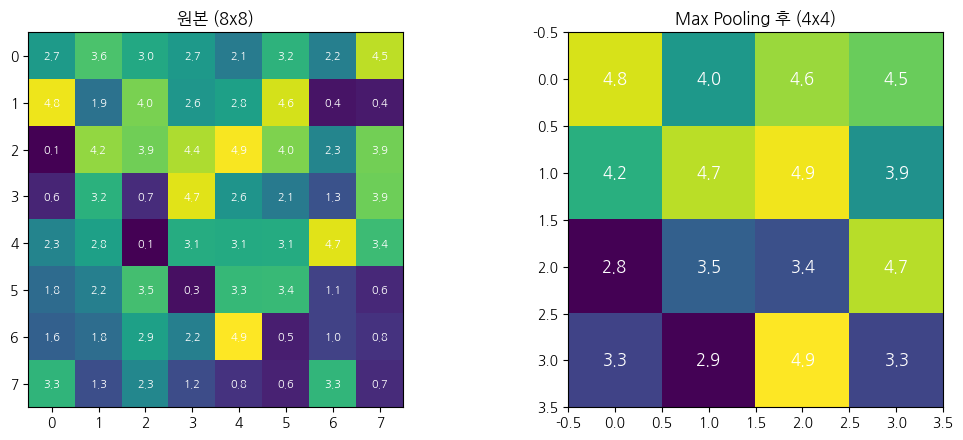

입력 (8, 8) -> 출력 (4, 4)
각 2x2 영역에서 최댓값만 살아남았습니다!


In [18]:
# 표준 정답 함수
def max_pool_2x2(image):
    H, W = image.shape
    H_out, W_out = H // 2, W // 2
    out = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            out[i, j] = image[i*2:(i+1)*2, j*2:(j+1)*2].max()
    return out

# 풀링 효과 시각화
np.random.seed(0)
random_img = np.random.rand(8, 8) * 5
pooled = max_pool_2x2(random_img)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].imshow(random_img, cmap='viridis')
axes[0].set_title(f'원본 ({random_img.shape[0]}x{random_img.shape[1]})')
for i in range(8):
    for j in range(8):
        axes[0].text(j, i, f'{random_img[i,j]:.1f}', ha='center', va='center', fontsize=8, color='white')

axes[1].imshow(pooled, cmap='viridis')
axes[1].set_title(f'Max Pooling 후 ({pooled.shape[0]}x{pooled.shape[1]})')
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f'{pooled[i,j]:.1f}', ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.tight_layout(); plt.show()
print(f"입력 {random_img.shape} -> 출력 {pooled.shape}")
print(f"각 2x2 영역에서 최댓값만 살아남았습니다!")

## 8. ReLU 활성화 함수

### CNN의 일반적인 구성 패턴

> **합성곱(Conv) -> 활성화(ReLU) -> 풀링(Pool)**

이 세 가지가 한 세트입니다. 우리가 conv와 pool은 만들었으니, 마지막으로 ReLU를 만들어 봅시다.

### ReLU란?

> **Rectified Linear Unit** — 이름이 거창하지만 하는 일은 매우 단순:
> **음수면 0으로, 양수면 그대로**

수식: $\text{ReLU}(x) = \max(0, x)$

### 비유: 엄격한 게이트키퍼

> "음수 손님은 출입 금지! 양수 손님은 자유롭게 통과!"

### 왜 필요한가?

**비선형성 추가**: 합성곱은 사실 "선형 연산" (곱셈과 덧셈)입니다.
선형 연산을 아무리 많이 쌓아도 결국 하나의 선형 연산과 같아요 (수학적 사실).

> **선형 두 개 = 결국 한 개의 선형**
> **선형 + ReLU + 선형 + ReLU + ... = 매우 복잡한 함수!**

ReLU가 사이사이에 들어가야 모델이 **곡선, 비선형 패턴** 을 학습할 수 있습니다.

### 다른 활성화 함수들

- **ReLU**: 가장 일반적, 빠름 (요즘 표준)
- **Sigmoid**: 0~1 사이 (옛날에 많이 썼지만 기울기 소실 문제)
- **Tanh**: -1~1 사이
- **GELU, Swish**: ReLU의 발전형 (Transformer 등에 사용)

비전공자 입장에선 일단 **"ReLU = 음수는 0으로 자르기"** 만 기억하면 충분합니다.

---

## 연습 4: ReLU 함수 만들기

### 만들어야 할 함수
```python
relu(x)
# 입력: x (어떤 모양의 numpy 배열도 OK)
# 출력: 같은 모양, 음수는 모두 0으로
```

### 힌트 — 한 줄!

`np.maximum(0, x)` 한 줄이면 끝납니다.

> **np.maximum vs np.max 차이**:
> - `np.maximum(a, b)`: a와 b를 **같은 자리끼리 비교**해서 더 큰 것 (element-wise)
> - `np.max(arr)`: 배열의 **모든 원소 중 최댓값** (스칼라 1개)
>
> ReLU는 **각 원소마다** 0과 비교해서 큰 쪽을 골라야 하니까 `np.maximum` 사용!

### 다른 방법

`np.where(x > 0, x, 0)` 도 동일한 결과를 줍니다.
"x > 0 이면 x를, 아니면 0을" 이라는 의미예요.

In [19]:
# 빈칸을 채워서 ReLU 함수를 완성하세요!
def relu(x):
    # TODO: 음수는 0으로, 양수는 그대로
    return np.maximum(0, x)   # (힌트: np.maximum(0, x))

In [20]:
# 자가 검증
try:
    # 검증 1) 음수, 0, 양수 섞인 배열
    x = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
    expected = np.array([0.0, 0.0, 0.0, 0.5, 2.0])
    result = relu(x)

    # 검증 2) 2D 배열도 잘 동작하는지
    x2d = np.array([[-1, 2], [3, -4]])
    expected2d = np.array([[0, 2], [3, 0]])
    result2d = relu(x2d)

    # 검증 3) 모두 음수
    all_neg = np.array([-1, -2, -3])
    result_neg = relu(all_neg)

    ok1 = np.array_equal(result, expected)
    ok2 = np.array_equal(result2d, expected2d)
    ok3 = (result_neg == 0).all()

    if ok1 and ok2 and ok3:
        print(f"정답입니다!")
        print(f"   1D 입력: {x}")
        print(f"   1D 결과: {result}")
        print(f"   2D 입력:\n{x2d}")
        print(f"   2D 결과:\n{result2d}")
    else:
        print(f"다시 시도해보세요.")
        print(f"   1D 결과: {result} (기대: {expected})")
except Exception as e:
    print(f"에러 발생: {e}")

정답입니다!
   1D 입력: [-2.  -0.5  0.   0.5  2. ]
   1D 결과: [0.  0.  0.  0.5 2. ]
   2D 입력:
[[-1  2]
 [ 3 -4]]
   2D 결과:
[[0 2]
 [3 0]]


<details>
<summary>정답 보기 (클릭)</summary>

```python
def relu(x):
    return np.maximum(0, x)
```

**해설**:
- `np.maximum(0, x)`: 0과 x를 **같은 자리끼리** 비교해서 더 큰 쪽을 반환
- 1D, 2D, 3D, 4D 텐서 모두에 자동으로 동작합니다 (numpy 브로드캐스팅)
- 정말 단순하지만, 이 함수가 딥러닝의 폭발적 발전을 이끌었습니다!

</details>

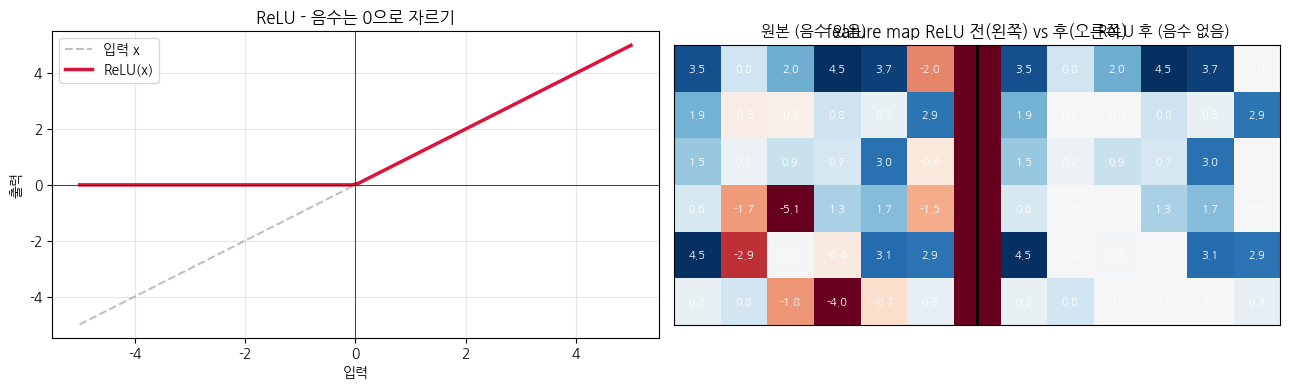

음수 개수: 원본 12개 -> ReLU 후 0개


In [21]:
# 표준 정답 함수
def relu(x):
    return np.maximum(0, x)

# ReLU 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 1D 그래프
x = np.linspace(-5, 5, 100)
axes[0].plot(x, x, '--', color='gray', alpha=0.5, label='입력 x')
axes[0].plot(x, relu(x), color='crimson', linewidth=2.5, label='ReLU(x)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('입력'); axes[0].set_ylabel('출력')
axes[0].set_title('ReLU - 음수는 0으로 자르기')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 2D feature map에 ReLU 적용 (음수 포함)
np.random.seed(0)
fmap = np.random.randn(6, 6) * 2  # 평균 0, 음수도 있음
fmap_relu = relu(fmap)

# 두 개를 나란히 (원래 axes[1]에 둘 다 표현)
combined = np.hstack([fmap, np.zeros((6, 1)) - 99, fmap_relu])
im = axes[1].imshow(combined, cmap='RdBu', vmin=-4, vmax=4)
axes[1].set_title('feature map ReLU 전(왼쪽) vs 후(오른쪽)')
axes[1].axvline(6, color='black', linewidth=2)
axes[1].text(2.5, -0.7, '원본 (음수 있음)', ha='center', fontsize=11)
axes[1].text(10, -0.7, 'ReLU 후 (음수 없음)', ha='center', fontsize=11)
axes[1].set_xticks([]); axes[1].set_yticks([])

# 숫자 표시
for i in range(6):
    for j in range(6):
        v = fmap[i, j]
        axes[1].text(j, i, f'{v:.1f}', ha='center', va='center',
                     color='white', fontsize=8)
        v_r = fmap_relu[i, j]
        axes[1].text(j + 7, i, f'{v_r:.1f}', ha='center', va='center',
                     color='white', fontsize=8)

plt.tight_layout(); plt.show()

print(f"음수 개수: 원본 {(fmap < 0).sum()}개 -> ReLU 후 {(fmap_relu < 0).sum()}개")

## 9. 미니 CNN — 만든 함수들로 끝까지 통과시키기!

이제 우리에게는 CNN의 모든 핵심 부품이 있습니다:
- `conv2d`: 합성곱
- `relu`: 활성화 함수
- `max_pool_2x2`: 풀링

이걸 순서대로 연결하면 **진짜 CNN의 forward pass**가 됩니다!

### 미니 CNN 구조

```
입력 이미지 (28x28)
   |
   v  Conv (5x5 필터)
특징맵 (24x24)
   |
   v  ReLU (음수 자르기)
활성화된 특징맵 (24x24)
   |
   v  Max Pool (2x2)
풀링된 특징맵 (12x12)
   |
   v  Flatten (1D로 펴기)
벡터 (144)
   |
   v  Fully Connected (분류기)
클래스 확률 (예: 10개)
```

> **이 구조가 LeNet-5(1998년 손글씨 인식)의 한 블록과 거의 같습니다!**
> 진짜 CNN은 이 블록을 **여러 개 쌓은 것**일 뿐입니다.

In [22]:
# 28x28 가짜 손글씨 이미지 만들기 (가운데에 'L자' 모양)
np.random.seed(42)
input_img = np.zeros((28, 28), dtype=np.float32)
# 'L자' 그리기: 세로선 + 가로선
input_img[6:22, 8:11] = 1.0     # 세로 막대
input_img[19:22, 8:20] = 1.0    # 가로 막대
# 약간의 노이즈
input_img += np.random.randn(28, 28) * 0.05

# 학습된 필터처럼 보이는 5x5 (사실은 우리가 손으로 만든)
# 가로/세로 엣지를 한꺼번에 검출하는 필터
my_filter = np.array([
    [-1, -1, -1, -1, -1],
    [-1,  2,  2,  2, -1],
    [-1,  2,  4,  2, -1],
    [-1,  2,  2,  2, -1],
    [-1, -1, -1, -1, -1],
], dtype=np.float32)

print("=" * 60)
print("미니 CNN forward pass 시작!")
print("=" * 60)

# Step 1: 합성곱
step1 = conv2d(input_img, my_filter)
print(f"\n[Step 1] Conv2D (28x28 + 5x5 filter)")
print(f"   입력 shape: {input_img.shape}")
print(f"   출력 shape: {step1.shape}  (24x24)")
print(f"   값 범위:    [{step1.min():.2f}, {step1.max():.2f}]  (음수도 있음)")

# Step 2: ReLU
step2 = relu(step1)
print(f"\n[Step 2] ReLU")
print(f"   shape:     {step2.shape}  (그대로)")
print(f"   값 범위:    [{step2.min():.2f}, {step2.max():.2f}]  (음수 사라짐!)")

# Step 3: Max Pooling
step3 = max_pool_2x2(step2)
print(f"\n[Step 3] Max Pool 2x2")
print(f"   입력 shape: {step2.shape}")
print(f"   출력 shape: {step3.shape}  (12x12, 절반!)")

# Step 4: Flatten
step4 = step3.flatten()
print(f"\n[Step 4] Flatten")
print(f"   shape:     {step4.shape}  (1D 벡터로!)")

# Step 5: Fully Connected (10개 클래스 분류, 가짜 가중치 사용)
np.random.seed(0)
fc_weights = np.random.randn(step4.shape[0], 10) * 0.01
fc_bias = np.zeros(10)
logits = step4 @ fc_weights + fc_bias
print(f"\n[Step 5] Fully Connected -> 10 클래스")
print(f"   shape:     {logits.shape}")
print(f"   가장 큰 값의 인덱스 (예측 클래스): {logits.argmax()}")

미니 CNN forward pass 시작!

[Step 1] Conv2D (28x28 + 5x5 filter)
   입력 shape: (28, 28)
   출력 shape: (24, 24)  (24x24)
   값 범위:    [-8.36, 17.00]  (음수도 있음)

[Step 2] ReLU
   shape:     (24, 24)  (그대로)
   값 범위:    [0.00, 17.00]  (음수 사라짐!)

[Step 3] Max Pool 2x2
   입력 shape: (24, 24)
   출력 shape: (12, 12)  (12x12, 절반!)

[Step 4] Flatten
   shape:     (144,)  (1D 벡터로!)

[Step 5] Fully Connected -> 10 클래스
   shape:     (10,)
   가장 큰 값의 인덱스 (예측 클래스): 6


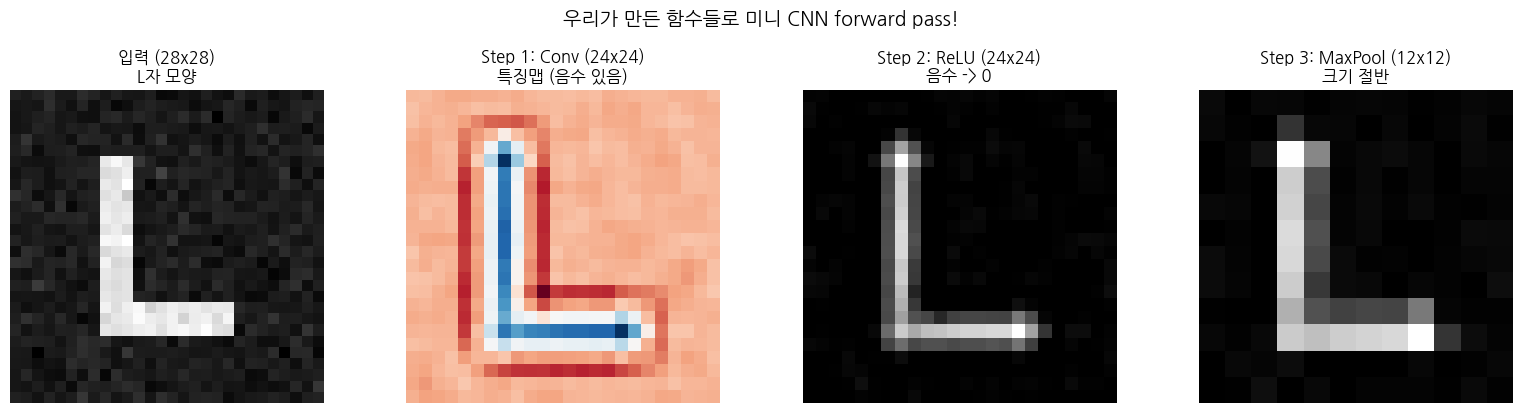


축하합니다! 진짜 CNN의 한 블록을 처음부터 끝까지 직접 만들었습니다.
LeNet-5, AlexNet, VGG, ResNet 같은 유명 CNN들도 이 블록을 더 많이 쌓은 것뿐입니다.


In [23]:
# 단계별 시각화
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(input_img, cmap='gray')
axes[0].set_title(f'입력 ({input_img.shape[0]}x{input_img.shape[1]})\nL자 모양')
axes[0].axis('off')

axes[1].imshow(step1, cmap='RdBu')
axes[1].set_title(f'Step 1: Conv ({step1.shape[0]}x{step1.shape[1]})\n특징맵 (음수 있음)')
axes[1].axis('off')

axes[2].imshow(step2, cmap='gray')
axes[2].set_title(f'Step 2: ReLU ({step2.shape[0]}x{step2.shape[1]})\n음수 -> 0')
axes[2].axis('off')

axes[3].imshow(step3, cmap='gray')
axes[3].set_title(f'Step 3: MaxPool ({step3.shape[0]}x{step3.shape[1]})\n크기 절반')
axes[3].axis('off')

plt.suptitle('우리가 만든 함수들로 미니 CNN forward pass!', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("\n축하합니다! 진짜 CNN의 한 블록을 처음부터 끝까지 직접 만들었습니다.")
print("LeNet-5, AlexNet, VGG, ResNet 같은 유명 CNN들도 이 블록을 더 많이 쌓은 것뿐입니다.")

## 자유 도전 과제

### 도전 1: 다른 필터 만들어보기
- 대각선 엣지 검출 필터를 만들어 보세요
- 예: `[[1,0,0],[0,0,0],[0,0,-1]]`

### 도전 2: 두 번 conv 쌓기
입력 -> Conv -> ReLU -> Conv -> ReLU -> Pool 처럼 **두 번 합성곱** 을 적용해 보세요.
출력 크기가 어떻게 변하는지 관찰!

### 도전 3: 평균 풀링 만들기
`max_pool_2x2` 함수를 복사하고 `.max()` 만 `.mean()` 으로 바꾸면 됩니다.
Max와 결과가 어떻게 다른지 비교해 보세요.

In [ ]:
# 자유 실험 공간
# 직접 새 필터를 만들거나, 다른 이미지에 적용해 보세요!

# 예: 대각선 엣지 검출
diagonal_filter = np.array([
    [ 2,  1,  0],
    [ 1,  0, -1],
    [ 0, -1, -2],
], dtype=np.float32)

# 사각형 이미지에 적용
square = np.zeros((20, 20), dtype=np.float32)
square[5:15, 5:15] = 1.0

result = conv2d(square, diagonal_filter)
result_relu = relu(result)
result_pool = max_pool_2x2(result_relu)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(square, cmap='gray'); axes[0].set_title('원본 사각형'); axes[0].axis('off')
axes[1].imshow(result, cmap='RdBu'); axes[1].set_title('대각선 필터 결과'); axes[1].axis('off')
axes[2].imshow(result_relu, cmap='gray'); axes[2].set_title('ReLU 후'); axes[2].axis('off')
axes[3].imshow(result_pool, cmap='gray'); axes[3].set_title('MaxPool 후'); axes[3].axis('off')
plt.tight_layout(); plt.show()

print(f"각 단계 shape:")
print(f"   원본:    {square.shape}")
print(f"   Conv 후: {result.shape}")
print(f"   ReLU 후: {result_relu.shape}")
print(f"   Pool 후: {result_pool.shape}")

## 10. 한 장으로 정리

### 오늘 직접 만든 것 4가지

1. **`conv_at`** — 한 위치의 합성곱 (곱하고 더하기)
2. **`conv2d`** — 슬라이딩 윈도우로 전체 합성곱
3. **`max_pool_2x2`** — 영역의 최댓값만 살리는 다운샘플링
4. **`relu`** — 음수를 0으로 자르는 활성화 함수

이 네 가지가 **CNN의 핵심 부품 전부**입니다!

### 핵심 용어 정리

| 용어 | 뜻 | 비유 |
|---|---|---|
| **필터(filter, kernel)** | 작은 가중치 행렬 (보통 3x3, 5x5) | 도장 |
| **특징맵(feature map)** | 합성곱 결과 이미지 | 도장으로 찍은 결과 |
| **패딩(padding)** | 이미지 가장자리에 0 두르기 | 종이에 여백 추가 |
| **스트라이드(stride)** | 도장을 몇 칸씩 옮길지 | 한 칸/두 칸씩 건너뛰기 |
| **풀링(pooling)** | 영역에서 대표값 뽑기 | 동네 대표 뽑기 |
| **활성화 함수(activation)** | 비선형성 추가 | 게이트키퍼 |

### 4번의 노트북 흐름 정리

| 노트북 | 핵심 |
|---|---|
| **1. 미니배치 GD** | 학습의 핵심 알고리즘 (산 내려오기) |
| **2. 다중분류** | 출력을 확률로 (Softmax + Cross-Entropy) |
| **3. 이미지 처리** | CNN에 넣을 데이터 준비 (정규화, 증강, 4D 텐서) |
| **4. 기본 CNN (오늘!)** | 진짜 CNN 부품 만들기 (Conv, Pool, ReLU) |

### 진짜 CNN과의 차이

오늘 만든 코드는 **개념을 이해하기 위한 단순한 버전**입니다.
실전 PyTorch/TensorFlow의 Conv2d는 다음 기능들이 더 있어요:

- **여러 채널 (RGB) 처리**: 입력이 (H, W, C)일 때
- **여러 필터 동시 적용**: 출력 채널이 32개, 64개 등
- **GPU 병렬 처리**: 모든 위치를 동시에 계산 (im2col + GEMM 트릭)
- **자동 미분**: 학습을 위한 backward pass

### 다음에 배울 만한 것

- **CNN 학습 (역전파, backpropagation)**: 필터를 어떻게 학습시키는지
- **유명 CNN 아키텍처**: LeNet -> VGG -> ResNet -> EfficientNet
- **전이 학습 (Transfer Learning)**: 남이 학습한 모델 가져와서 미세조정
- **객체 검출 (Object Detection)**: 사진에서 "어디에" 무엇이 있는지

---

> **수고하셨습니다!**
> 이제 누가 "CNN이 뭐예요?" 라고 물으면
> "필터를 슬라이딩하며 곱하고 더해서 특징맵을 만들고, ReLU로 음수를 자르고, 풀링으로 크기를 줄이는 신경망입니다"
> 라고 한 문장으로 답할 수 있어요. 이 문장의 모든 단어를 직접 코드로 만들어 봤으니까요!